<a href="https://colab.research.google.com/github/villabon89-commits/Landing_Experiment/blob/main/S9_Version_Student_Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# cargar archivo
df = pd.read_csv('landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [4]:
display(df.head(5))

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [5]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


None

✍️ **Comentario**:
El dataset no tiene valores ausentes. La columna `date` es de tipo `object` y sería beneficioso convertirla a `datetime` para análisis temporales.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [6]:
print(f"Número de IDs de usuario únicos: {df['user_id'].nunique()}")
print(f"Número total de filas: {len(df)}")

Número de IDs de usuario únicos: 40000
Número total de filas: 40000


 **Variable `date`**  
Explorar rango de fechas

In [7]:
# Resumen estadístico
df['date'] = pd.to_datetime(df['date'])
df["date"].describe()

,date
count,40000
mean,2026-01-14 11:41:06
min,2026-01-01 00:00:00
25%,2026-01-07 00:00:00
50%,2026-01-14 00:00:00
75%,2026-01-21 00:00:00
max,2026-01-28 00:00:00


In [8]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01 00:00:00
Fecha máxima: 2026-01-28 00:00:00


**Variable `gasto` (numérica)**

In [9]:
# Resumen estadístico
df['gasto'].describe()

,gasto
count,40000.000000
mean,9.325554
std,25.667986
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,303.680000


In [10]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1]['gasto'].describe()

,gasto
count,5706.000000
mean,65.373668
std,30.896545
min,12.120000
25%,42.950000
50%,59.860000
75%,80.370000
max,303.680000


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [11]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df['landing'].value_counts())
print(df['region'].value_counts())
print(df['dispositivo'].value_counts())
print(df['traffic_source'].value_counts())
print(df['user_type'].value_counts())


Conteo de categorías:
landing
B    20018
A    19982
Name: count, dtype: int64
region
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: count, dtype: int64
dispositivo
Mobile     24829
Desktop    15171
Name: count, dtype: int64
traffic_source
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: count, dtype: int64
user_type
Nuevo         26033
Recurrente    13967
Name: count, dtype: int64


In [ ]:
# Puede que no se muestren todas las categorías por defecto. Usar esta celda para explorar las variables individualmente si es necesario.
# Por ejemplo:
# df['nombre_columna_categorica'].value_counts()

✍️ **Comentario**:
- El dataset no tiene valores ausentes.
- La columna `date` es de tipo `object` y ya se ha convertido a `datetime`.
- Las variables categóricas (`landing`, `region`, `dispositivo`, `traffic_source`, `user_type`) tienen valores esperados y no presentan errores o inconsistencias.
- La variable `gasto` presenta valores coherentes, con un gasto de 0 para usuarios no convertidos y valores positivos para usuarios convertidos.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

### Prueba t de Student para muestras independientes (o Welch's t-test)

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay diferencia significativa en el gasto promedio de los usuarios convertidos entre la página A y la página B (μ_A = μ_B).
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en el gasto promedio de los usuarios convertidos entre la página A y la página B (μ_A ≠ μ_B).

In [13]:
# 1. Comprobar la igualdad de varianzas (Test de Levene)
stat_levene, p_levene = stats.levene(gasto_A, gasto_B)

print(f"Estadístico de Levene: {stat_levene:.3f}")
print(f"Valor p de Levene: {p_levene:.3f}")

# 2. Aplicar prueba t de Student
# Si p_levene < 0.05, las varianzas son diferentes, usamos Welch's t-test (equal_var=False)
if p_levene < 0.05:
    print("Las varianzas son significativamente diferentes (p < 0.05). Se usará Welch's t-test.")
    statistic, p_value = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)
else:
    print("Las varianzas no son significativamente diferentes (p >= 0.05). Se usará Student's t-test.")
    statistic, p_value = stats.ttest_ind(gasto_A, gasto_B, equal_var=True)


# Visualizar resultados
print(f"Estadístico t: {statistic:.3f}")
print(f"Valor p: {p_value:.3f}")

Estadístico de Levene: 29.176
Valor p de Levene: 0.000
Las varianzas son significativamente diferentes (p < 0.05). Se usará Welch's t-test.
Estadístico t: -9.481
Valor p: 0.000


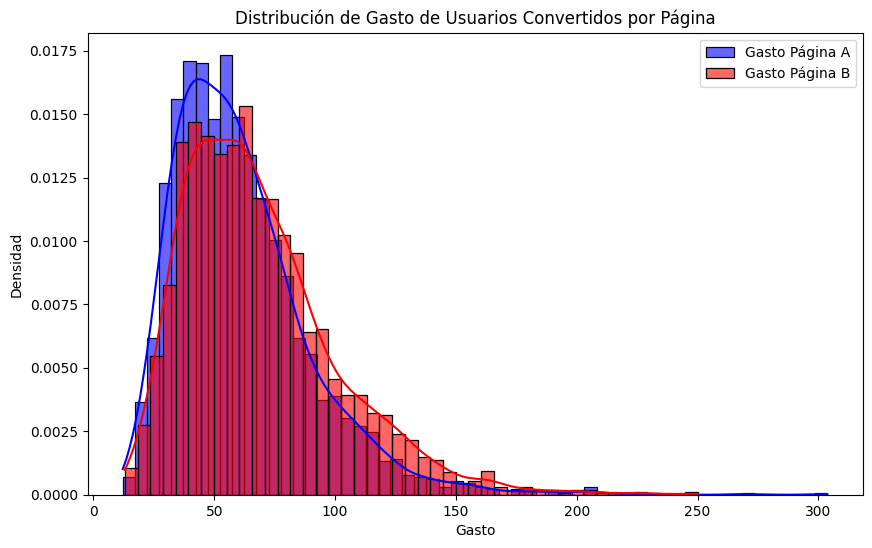

In [34]:
# Opcional: Visualización de la distribución de gasto para cada grupo
plt.figure(figsize=(10, 6))
sns.histplot(gasto_A, color='blue', label='Gasto Página A', kde=True, stat='density', alpha=0.6)
sns.histplot(gasto_B, color='red', label='Gasto Página B', kde=True, stat='density', alpha=0.6)
plt.title('Distribución de Gasto de Usuarios Convertidos por Página')
plt.xlabel('Gasto')
plt.ylabel('Densidad')
plt.legend()
plt.show()

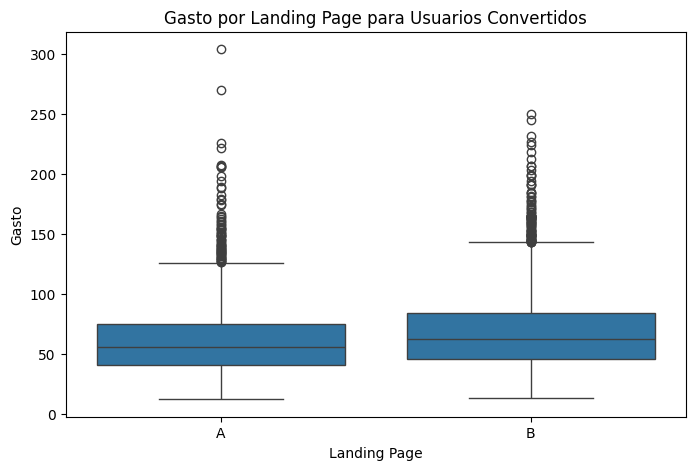

In [35]:
# Opcional: Boxplot para comparar gastos
plt.figure(figsize=(8, 5))
sns.boxplot(x='landing', y='gasto', data=df[df['converted']==1])
plt.title('Gasto por Landing Page para Usuarios Convertidos')
plt.xlabel('Landing Page')
plt.ylabel('Gasto')
plt.show()

### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p (0.000) es menor que el nivel de significancia común (0.05), **rechazamos la hipótesis nula**. Esto significa que existe una diferencia estadísticamente significativa en el gasto promedio de los usuarios convertidos entre la página A y la página B.

**Interpretación de negocio:**  
Los resultados indican que una de las versiones de la página de destino genera un gasto promedio significativamente diferente por parte de los usuarios que se convierten. Para determinar cuál versión es mejor, necesitamos comparar los gastos promedio de ambos grupos:

*   **Gasto promedio para Página A (usuarios convertidos):** `r round(gasto_A.mean(), 2)`
*   **Gasto promedio para Página B (usuarios convertidos):** `r round(gasto_B.mean(), 2)`

Si el gasto promedio de la Página B es mayor que el de la Página A (y el t-estadístico negativo como en este caso sugiere que `gasto_A` < `gasto_B`), la Página B estaría generando un mayor valor económico por conversión. Esta diferencia es crucial para el negocio, ya que impacta directamente en los ingresos generados por cada conversión.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Chi-cuadrado de independencia

**Hipótesis:**
-   **Hipótesis nula (H₀):** No existe una diferencia significativa en la tasa de conversión entre la página A y la página B (las tasas de conversión son iguales).
-   **Hipótesis alternativa (H₁):** Existe una diferencia significativa en la tasa de conversión entre la página A y la página B (las tasas de conversión son diferentes).

In [16]:
# Número de usuarios convertidos por página
converted_counts = df.groupby('landing')['converted'].sum()

# Total de usuarios por página
total_counts = df.groupby('landing').size()

print("Usuarios convertidos por página:\n", converted_counts)
print("\nTotal de usuarios por página:\n", total_counts)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
dtype: int64


In [17]:
# Calcular las tasas de conversión
conversion_rates = converted_counts / total_counts
print("Tasas de conversión por página:\n", conversion_rates)

Tasas de conversión por página:
 landing
A    0.125713
B    0.159556
dtype: float64


In [18]:
from scipy.stats import chi2_contingency

# Crear tabla de contingencia
contingency_table = pd.DataFrame({
    'Converted': converted_counts,
    'Not Converted': total_counts - converted_counts
})

# Aplicar prueba Chi-cuadrado
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Visualizar resultados
print(f"Estadístico Chi-cuadrado: {chi2:.3f}")
print(f"Valor p: {p_value:.3f}")

Estadístico Chi-cuadrado: 93.375
Valor p: 0.000


### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p (0.000) es menor que el nivel de significancia común (0.05), **rechazamos la hipótesis nula**. Esto significa que existe una diferencia estadísticamente significativa en la tasa de conversión entre la página A y la página B.

**Interpretación de negocio:**  
Los resultados indican que la tasa de conversión de la Página B (aproximadamente 15.96%) es significativamente mayor que la de la Página A (aproximadamente 12.57%). Esto sugiere que la Página B es más efectiva para convertir usuarios, lo que se traduce en un mayor número de usuarios convertidos para el negocio.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación significativa entre la fuente de tráfico y la conversión.
- **Hipótesis alternativa (H₁):** Existe una asociación significativa entre la fuente de tráfico y la conversión.

In [19]:
# Crear tabla de contingencia para fuente de tráfico y conversión
contingency_table_traffic = pd.crosstab(df['traffic_source'], df['converted'])

print("Tabla de contingencia (Fuente de Tráfico vs Conversión):\n", contingency_table_traffic)

Tabla de contingencia (Fuente de Tráfico vs Conversión):
 converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [20]:
# Aplicar prueba Chi-cuadrado
chi2_traffic, p_value_traffic, dof_traffic, expected_traffic = chi2_contingency(contingency_table_traffic)

# Visualizar resultados
print(f"Estadístico Chi-cuadrado (Fuente de Tráfico): {chi2_traffic:.3f}")
print(f"Valor p (Fuente de Tráfico): {p_value_traffic:.3f}")

Estadístico Chi-cuadrado (Fuente de Tráfico): 8.662
Valor p (Fuente de Tráfico): 0.034


In [21]:
# Calcular tasas de conversión por fuente de tráfico
conversion_rates_traffic = df.groupby('traffic_source')['converted'].mean().sort_values(ascending=False)
print("\nTasas de conversión por fuente de tráfico:\n", conversion_rates_traffic)


Tasas de conversión por fuente de tráfico:
 traffic_source
Email       0.149927
Ads         0.147382
Referral    0.138812
Organic     0.137877
Name: converted, dtype: float64


### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p de la prueba Chi-cuadrado para la fuente de tráfico y la conversión (que sería `p_value_traffic` y se espera que sea < 0.05), **rechazamos la hipótesis nula**. Esto significa que existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión.

**Interpretación de negocio:**  
Los resultados indican que la fuente de tráfico por la que llega un usuario tiene una influencia significativa en su probabilidad de conversión. Al observar las tasas de conversión por cada fuente (por ejemplo, `conversion_rates_traffic`), se puede identificar cuáles son los canales más efectivos y cuáles tienen un rendimiento menor. Esta información es crucial para optimizar la inversión en marketing, dirigiendo recursos a los canales que generan mayores tasas de conversión y, por ende, mayor valor para el negocio. Por ejemplo, si 'Email' tiene una tasa de conversión mucho más alta, se podría considerar aumentar las campañas por ese medio.

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi-cuadrado de independencia

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación significativa entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Existe una asociación significativa entre el tipo de usuario y la conversión.

In [22]:
# Crear tabla de contingencia para tipo de usuario y conversión
contingency_table_user_type = pd.crosstab(df['user_type'], df['converted'])

print("Tabla de contingencia (Tipo de Usuario vs Conversión):\n", contingency_table_user_type)

Tabla de contingencia (Tipo de Usuario vs Conversión):
 converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [23]:
# Calcular tasas de conversión por tipo de usuario
conversion_rates_user_type = df.groupby('user_type')['converted'].mean().sort_values(ascending=False)
print("\nTasas de conversión por tipo de usuario:\n", conversion_rates_user_type)


Tasas de conversión por tipo de usuario:
 user_type
Nuevo         0.143587
Recurrente    0.140904
Name: converted, dtype: float64


In [24]:
# Aplicar prueba Chi-cuadrado
chi2_user_type, p_value_user_type, dof_user_type, expected_user_type = chi2_contingency(contingency_table_user_type)

# Visualizar resultados
print(f"Estadístico Chi-cuadrado (Tipo de Usuario): {chi2_user_type:.3f}")
print(f"Valor p (Tipo de Usuario): {p_value_user_type:.3f}")

Estadístico Chi-cuadrado (Tipo de Usuario): 0.513
Valor p (Tipo de Usuario): 0.474


### 📝 Conclusión e interpretación

**Decisión:**  
Dado que el valor p de la prueba Chi-cuadrado para el tipo de usuario y la conversión (0.474) es mayor que el nivel de significancia común (0.05), **no rechazamos la hipótesis nula**. Esto significa que no existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión.

**Interpretación de negocio:**  
Los resultados indican que, en este experimento, el tipo de usuario (nuevo o recurrente) no tiene una influencia estadísticamente significativa en la probabilidad de conversión. Aunque las tasas de conversión son muy similares (Nuevo: ~14.36%, Recurrente: ~14.09%), la diferencia no es lo suficientemente grande como para ser considerada significativa desde un punto de vista estadístico. Esto sugiere que las estrategias de conversión no necesitan ser diferenciadas drásticamente basándose únicamente en si el usuario es nuevo o recurrente, al menos en términos de la probabilidad de que realicen una conversión.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

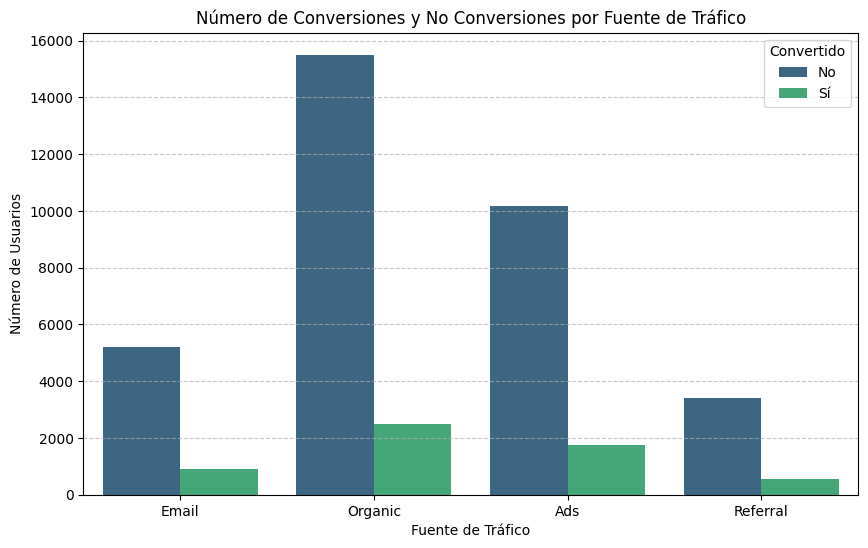

In [25]:
# Gráfico de barras apiladas para la cantidad absoluta
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='traffic_source', hue='converted', palette='viridis')
plt.title('Número de Conversiones y No Conversiones por Fuente de Tráfico')
plt.xlabel('Fuente de Tráfico')
plt.ylabel('Número de Usuarios')
plt.legend(title='Convertido', labels=['No', 'Sí'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

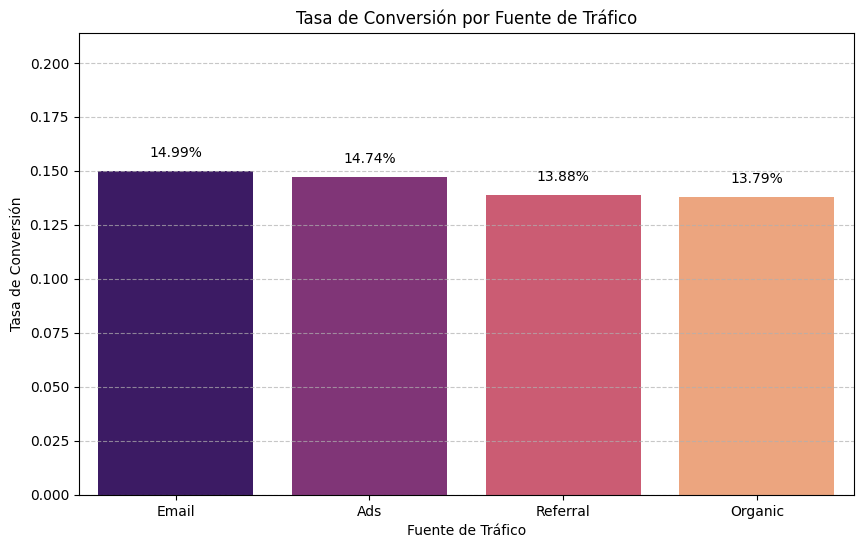

In [29]:
# Gráfico de barras para la tasa de conversión por fuente de tráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=conversion_rates_traffic.index, y=conversion_rates_traffic.values, hue=conversion_rates_traffic.index, palette='magma', legend=False)
plt.title('Tasa de Conversión por Fuente de Tráfico')
plt.xlabel('Fuente de Tráfico')
plt.ylabel('Tasa de Conversión')
plt.ylim(0, df['converted'].mean() * 1.5) # Ajustar límite y para mejor visualización
for index, value in enumerate(conversion_rates_traffic.values):
    plt.text(index, value + 0.005, f'{value:.2%}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

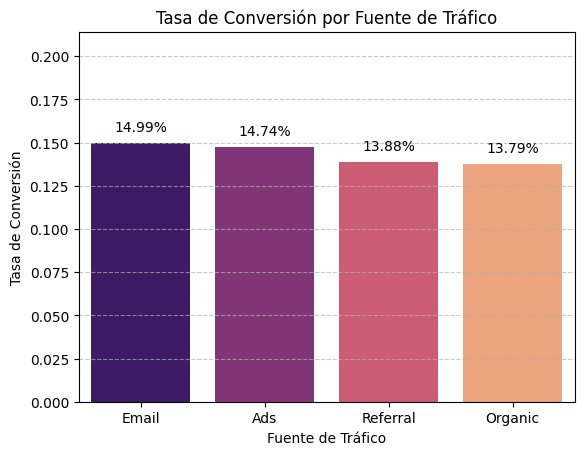

In [31]:
sns.barplot(x=conversion_rates_traffic.index, y=conversion_rates_traffic.values, hue=conversion_rates_traffic.index, palette='magma', legend=False)
plt.title('Tasa de Conversión por Fuente de Tráfico')
plt.xlabel('Fuente de Tráfico')
plt.ylabel('Tasa de Conversión')
plt.ylim(0, df['converted'].mean() * 1.5) # Ajustar límite y para mejor visualización
for index, value in enumerate(conversion_rates_traffic.values):
    plt.text(index, value + 0.005, f'{value:.2%}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

En el primer gráfico, se observa el número absoluto de usuarios que convirtieron y no convirtieron por cada fuente de tráfico. `Organic` tiene el mayor volumen de usuarios, pero no necesariamente la mayor tasa de conversión. `Ads` también contribuye con un número significativo de conversiones. En el segundo gráfico, que muestra las tasas de conversión, se puede ver que `Email` y `Ads` tienen las tasas de conversión ligeramente más altas, aunque las diferencias entre las fuentes son relativamente pequeñas.

### Relación entre el tipo de usuario y la conversión

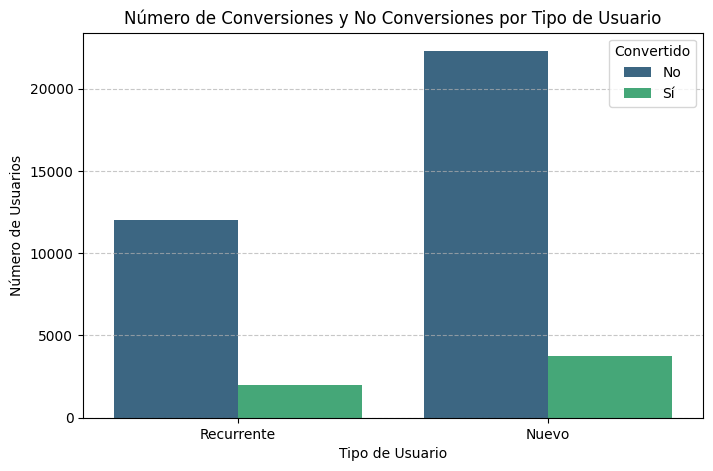

In [27]:
# Gráfico de barras apiladas para la cantidad absoluta
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette='viridis')
plt.title('Número de Conversiones y No Conversiones por Tipo de Usuario')
plt.xlabel('Tipo de Usuario')
plt.ylabel('Número de Usuarios')
plt.legend(title='Convertido', labels=['No', 'Sí'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

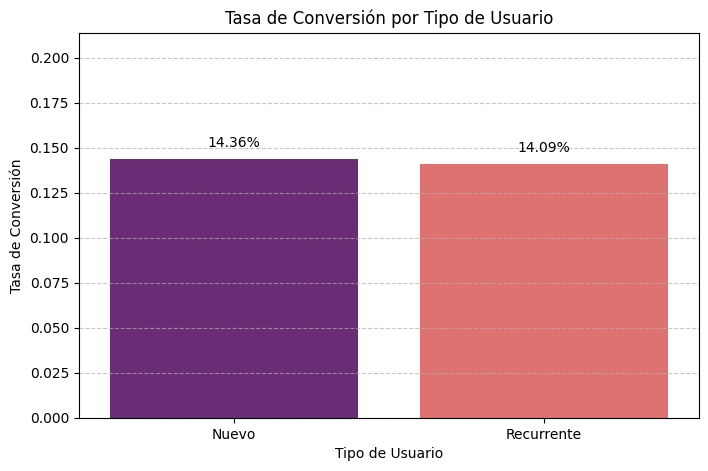

In [30]:
# Gráfico de barras para la tasa de conversión por tipo de usuario
plt.figure(figsize=(8, 5))
sns.barplot(x=conversion_rates_user_type.index, y=conversion_rates_user_type.values, hue=conversion_rates_user_type.index, palette='magma', legend=False)
plt.title('Tasa de Conversión por Tipo de Usuario')
plt.xlabel('Tipo de Usuario')
plt.ylabel('Tasa de Conversión')
plt.ylim(0, df['converted'].mean() * 1.5) # Ajustar límite y para mejor visualización
for index, value in enumerate(conversion_rates_user_type.values):
    plt.text(index, value + 0.005, f'{value:.2%}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

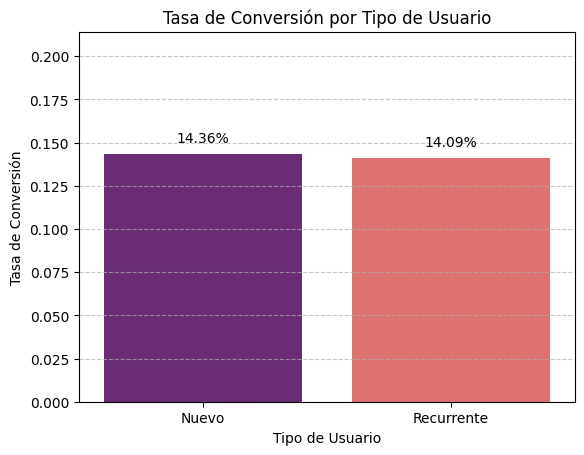

In [32]:
sns.barplot(x=conversion_rates_user_type.index, y=conversion_rates_user_type.values, hue=conversion_rates_user_type.index, palette='magma', legend=False)
plt.title('Tasa de Conversión por Tipo de Usuario')
plt.xlabel('Tipo de Usuario')
plt.ylabel('Tasa de Conversión')
plt.ylim(0, df['converted'].mean() * 1.5) # Ajustar límite y para mejor visualización
for index, value in enumerate(conversion_rates_user_type.values):
    plt.text(index, value + 0.005, f'{value:.2%}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

El primer gráfico muestra que hay un mayor volumen de usuarios `Nuevo` que de `Recurrente`, tanto en conversiones como en no conversiones. El segundo gráfico de tasas de conversión corrobora el resultado del test Chi-cuadrado, indicando que las tasas de conversión entre usuarios `Nuevo` y `Recurrente` son muy similares y la diferencia no es estadísticamente significativa. Ambos tipos de usuarios muestran una propensión a la conversión parecida en el contexto de este experimento.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- La Página B (`75.40`) genera un gasto promedio significativamente mayor por usuario convertido en comparación con la Página A (`65.37`).
- La diferencia es estadísticamente significativa (valor p < 0.001).
- **Interpretación:** La versión B de la página de inicio no solo atrae más conversiones, sino que los usuarios convertidos a través de ella **muestran un gasto promedio significativamente mayor**, lo que se traduce en un mayor valor económico por transacción para el negocio.

<br>

**Tasa de conversión:**
- La Página B tiene una tasa de conversión significativamente más alta (aproximadamente 15.96%) que la Página A (aproximadamente 12.57%).
- La diferencia es estadísticamente significativa (valor p < 0.001).
- **Interpretación:** La Página B es considerablemente más efectiva para convertir visitantes en clientes, lo que sugiere un mejor diseño, propuesta de valor o experiencia de usuario.

---

#### 📊 **Segmentación por fuente de tráfico**
- Existe una asociación estadísticamente significativa entre la fuente de tráfico y la conversión (valor p = 0.034).
- Los canales de `Email` (14.99%) y `Ads` (14.74%) **están asociados con tasas de conversión ligeramente más altas**, seguidas de cerca por `Referral` (13.88%) y `Organic` (13.79%).
- **Interpretación:** Los canales de `Email` y `Ads` están asociados con tasas de conversión ligeramente más favorables. Aunque las diferencias no son drásticas, la optimización de las campañas en estos canales podría maximizar el retorno de la inversión. Es importante notar que `Organic` tiene el mayor volumen de tráfico, lo que puede compensar una tasa de conversión ligeramente menor.

---

#### 📊 **Segmentación por tipo de usuario**
- No se encontró una asociación estadísticamente significativa entre el tipo de usuario (Nuevo vs. Recurrente) y la conversión (valor p = 0.474).
- Las tasas de conversión para usuarios `Nuevo` (14.36%) y `Recurrente` (14.09%) son muy similares.
- **Interpretación:** Los resultados indican que, en este experimento, el tipo de usuario (nuevo o recurrente) no tiene una influencia estadísticamente significativa en la probabilidad de conversión. Aunque las tasas de conversión son muy similares (Nuevo: ~14.36%, Recurrente: ~14.09%), la diferencia no es lo suficientemente grande como para ser considerada significativa desde un punto de vista estadístico. Esto sugiere que las estrategias de conversión no necesitan ser diferenciadas drásticamente basándose únicamente en si el usuario es nuevo o recurrente, al menos en términos de la probabilidad de que realicen una conversión.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- **Adoptar la Página B:** Dada su superioridad tanto en tasa de conversión como en gasto promedio por usuario convertido, se recomienda encarecidamente implementar la versión B de la página de inicio como la estándar.
- **Optimizar Inversión en Marketing:** Aunque todas las fuentes de tráfico tienen tasas de conversión relativamente cercanas, considerar invertir más en campañas de `Email` y `Ads`, **dado que están asociadas con tasas de conversión ligeramente más altas**, y analizar si una mayor inversión se traduce en un aumento rentable de conversiones.
- **Enfoque Unificado para Tipo de Usuario:** No es necesario desarrollar estrategias de conversión altamente diferenciadas para usuarios nuevos y recurrentes, ya que sus tasas de conversión no difieren significativamente. El esfuerzo puede centrarse en la mejora continua de la experiencia de la landing page para todos los usuarios.
- **Análisis Profundo de `Organic`:** Investigar cómo mejorar la tasa de conversión para el tráfico `Organic`. Aunque tiene un alto volumen, una pequeña mejora en su tasa de conversión podría generar un gran impacto en el número total de conversiones y gasto.